# Homopolymer and Di- to Hexanucleotide Microsatellite Loci — Phylo Tree + Heatmap

This notebook generates a figure combining:
- **Left**: bootstrapped phylogenetic tree (dendrogram format, one row per cell)
- **Right**: heatmap of repeat-unit deviation from a **pooled per-locus baseline** (median or mode): one value per cell (**more extreme** of the two HipSTR alleles, signed)

Loci (columns) are ordered by hierarchical clustering to group clone-discriminating signals together.  
**Run with the `retrace2` conda environment kernel.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.colors import TwoSlopeNorm
from Bio import Phylo
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.size'] = 8

print('matplotlib:', matplotlib.__version__)

matplotlib: 3.10.9


## TW1nt12k

Tree + HipSTR artefacts in `results_TW1nt12k_500targets_minqual0_minreads10/`; clone colours from `20210920_HCT116_1nt12k_samplesheet.csv`. Run imports, then paths through the plotting cell below for the TW figures.


In [2]:
# ── Paths ───────────────────────────────────────────────────────────────────
VCF_PATH        = 'results_TW1nt12k_500targets_minqual0_minreads10/hipstr/20210920_HCT116_TW1nt12k.vcf'
TREE_PATH       = 'results_TW1nt12k_500targets_minqual0_minreads10/phylo/20210920_HCT116_TW1nt12k_rerun.buildPhylo.newick-bootstrap.txt'
SAMPLE_LIST     = 'results_TW1nt12k_500targets_minqual0_minreads10/hipstr/20210920_HCT116_TW1nt12k.sample_list.txt'
SAMPLE_SHEET    = '20210920_HCT116_1nt12k_samplesheet.csv'

# ── Filtering parameters ─────────────────────────────────────────────────────
MIN_COVERAGE    = 0.80   # minimum fraction of cells with a call per locus
MIN_STD         = 0.00   # minimum std of repeat-unit change across cells (pre-filter only)
ALLELE_BASELINE = 'median'  # 'median' | 'mode' — center each locus (pooled alleles); median is robust to skew / stutter shoulders
BASELINE_INTEGER = True   # snap baseline to integer repeat units (round pool, then median/mode → nearest int; avoids half-repeat drift)
VISUAL_COLUMN_CENTER = True  # for heatmap only: subtract each column's mode of plotted values → white ≈ most common cell summary
VISUAL_COLUMN_STAT = 'mode'    # 'mode' | 'median' — baseline per column on finite heatmap cells (display only; F-stats unchanged)

# ── Figure parameters ────────────────────────────────────────────────────────
VMIN, VMAX      = -2, 2  # repeat-unit change color scale limits
MAX_LOCI        = 150    # cap on number of loci to display (top by variance)
OUT_PDF         = '20210920_HCT116_TW1nt12k_phylo_heatmap.pdf'
OUT_PNG         = '20210920_HCT116_TW1nt12k_phylo_heatmap.png'

In [3]:
# ── Parse VCF → GB matrix (repeat-unit change from reference) ───────────────
def parse_vcf_both_alleles(vcf_path, keep_samples=None):
    """
    Parse a HipSTR VCF and return TWO DataFrames (rows=loci, cols=samples):
        gb_lo  — the smaller of the two phased alleles (repeat-unit change)
        gb_hi  — the larger of the two phased alleles

    Both alleles are kept as separate integer repeat-unit values.
    We sort lo≤hi so the representation is consistent regardless of the
    arbitrary HipSTR phasing assignment (which allele is 'first' in a
    single-cell WGA diploid call has no meaningful biological interpretation).
    NaN where the call is missing.
    """
    rows_lo, rows_hi = [], []
    samples = None
    keep    = set(keep_samples) if keep_samples is not None else None

    with open(vcf_path) as fh:
        for line in fh:
            if line.startswith('##'):
                continue
            if line.startswith('#CHROM'):
                samples = line.lstrip('#').strip().split('\t')[9:]
                continue

            fields   = line.strip().split('\t')
            locus_id = fields[2]
            fmt_keys = fields[8].split(':')
            if 'GB' not in fmt_keys:
                continue
            gb_idx = fmt_keys.index('GB')

            period = 1
            for tag in fields[7].split(';'):
                if tag.startswith('PERIOD='):
                    period = int(tag.split('=')[1])
                    break

            row_lo = {'locus': locus_id}
            row_hi = {'locus': locus_id}
            for i, samp in enumerate(samples):
                if keep is not None and samp not in keep:
                    continue
                sval   = fields[9 + i].split(':')
                gb_str = sval[gb_idx] if gb_idx < len(sval) else '.'

                if gb_str == '.' or '.' in gb_str.split('|'):
                    row_lo[samp] = row_hi[samp] = np.nan
                    continue
                try:
                    a1, a2 = sorted(float(x) / period for x in gb_str.split('|'))
                    row_lo[samp] = a1   # smaller allele
                    row_hi[samp] = a2   # larger allele
                except ValueError:
                    row_lo[samp] = row_hi[samp] = np.nan

            rows_lo.append(row_lo)
            rows_hi.append(row_hi)

    def _to_df(rows):
        df = pd.DataFrame(rows).set_index('locus')
        if keep_samples is not None:
            df = df[[s for s in keep_samples if s in df.columns]]
        return df

    return _to_df(rows_lo), _to_df(rows_hi)


sample_list = open(SAMPLE_LIST).read().strip().split('\n')
print(f'Samples: {len(sample_list)}')

gb_lo, gb_hi = parse_vcf_both_alleles(VCF_PATH, keep_samples=sample_list)
print(f'Both-allele matrices: {gb_lo.shape[0]} loci × {gb_lo.shape[1]} cells')
print('gb_lo = smaller allele, gb_hi = larger allele')
gb_lo.head(3)

Samples: 34
Both-allele matrices: 2168 loci × 34 cells
gb_lo = smaller allele, gb_hi = larger allele


,2-1-C4_3-7-G7_Plate1-1E,2-1-C4_3-7-G7_Plate1-2B,2-1-C4_3-7-G7_Plate1-2C,2-1-C4_3-7-G7_Plate1-2D,2-1-C4_3-7-G7_Plate1-2F,2-1-C4_3-7-G7_Plate1-2G,2-1-C4_3-7-G7_Plate1-3B,2-1-C4_3-7-G7_Plate1-3C,2-1-C4_3-7-G7_Plate1-3G,2-1-F7_3-3-B9_Plate1-4B,...,2-1-H9_3-4-D8_Plate1-7C,2-1-H9_3-4-D8_Plate1-7D,2-1-H9_3-4-D8_Plate1-7E,2-1-H9_3-4-D8_Plate1-7F,2-1-H9_3-4-D8_Plate1-8B,2-1-H9_3-4-D8_Plate1-8F,2-1-H9_3-4-D8_Plate1-8G,2-1-H9_3-4-D8_Plate1-9B,2-1-H9_3-4-D8_Plate1-9D,2-1-H9_3-4-D8_Plate1-9G
locus,,,,,,,,,,,,,,,,,,,,,
chr1:6606666-6606681_15xA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chr1:6740252-6740268_16xT,-4.0,NaN,-3.0,NaN,NaN,NaN,NaN,-2.0,NaN,NaN,...,-3.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
chr1:6744232-6744253_21xT,-11.0,NaN,NaN,NaN,NaN,-8.0,NaN,NaN,NaN,-1.0,...,-3.0,-1.0,-10.0,-10.0,-4.0,NaN,NaN,NaN,NaN,NaN


In [4]:
# ── Coverage filter (applied to both allele matrices jointly) ─────────────────
# A locus passes if both alleles are called in ≥ MIN_COVERAGE of cells.
coverage = (gb_lo.notna() & gb_hi.notna()).mean(axis=1)
loci_covered = coverage[coverage >= MIN_COVERAGE].index
print(f'Loci with ≥{MIN_COVERAGE*100:.0f}% coverage (both alleles): {len(loci_covered)}')

gb_lo_filt = gb_lo.loc[loci_covered]
gb_hi_filt = gb_hi.loc[loci_covered]

Loci with ≥80% coverage (both alleles): 311


In [5]:
# ── Normalize each locus to a pooled baseline (median or mode of alleles) ─────
#
# Subtract pooled baseline (median or mode). With BASELINE_INTEGER, alleles are rounded to the nearest repeat before computing baseline,
# then baseline is rounded to int — fixes columns that look wrong when the raw median sits between 11 and 12 (many ±0.5 vs ±1).

MAX_NORM = VMAX

norm_lo, norm_hi = {}, {}
kept_loci = []

for locus in loci_covered:
    lo_vals = gb_lo_filt.loc[locus].dropna()
    hi_vals = gb_hi_filt.loc[locus].dropna()
    all_vals = pd.concat([lo_vals, hi_vals]).astype(float)
    if len(all_vals) == 0:
        continue
    pool = np.round(all_vals) if BASELINE_INTEGER else all_vals
    if ALLELE_BASELINE == 'median':
        raw = float(np.median(pool))
        baseline = float(round(raw)) if BASELINE_INTEGER else raw
    elif ALLELE_BASELINE == 'mode':
        modes = pd.Series(pool).mode()
        baseline = float(round(float(modes.iloc[0]))) if BASELINE_INTEGER else float(modes.iloc[0])
    else:
        raise ValueError("ALLELE_BASELINE must be 'median' or 'mode'")
    lo_norm = gb_lo_filt.loc[locus] - baseline
    hi_norm = gb_hi_filt.loc[locus] - baseline
    if lo_norm.dropna().abs().max() > MAX_NORM or hi_norm.dropna().abs().max() > MAX_NORM:
        continue
    norm_lo[locus] = lo_norm
    norm_hi[locus] = hi_norm
    kept_loci.append(locus)

gb_norm_lo = pd.DataFrame(norm_lo).T
gb_norm_hi = pd.DataFrame(norm_hi).T

print(f'Loci after ±{MAX_NORM} filter: {len(kept_loci)}  (dropped {len(loci_covered) - len(kept_loci)} noisy loci)')
ex = kept_loci[0] if kept_loci else None
if ex:
    print(f'\nExample locus: {ex}')
    print(f'  lo (first 5): {gb_norm_lo.loc[ex].dropna().values[:5]}')
    print(f'  hi (first 5): {gb_norm_hi.loc[ex].dropna().values[:5]}')



Loci after ±2 filter: 147  (dropped 164 noisy loci)

Example locus: chr1:36728604-36728622_18xT
  lo (first 5): [0. 0. 0. 0. 0.]
  hi (first 5): [1. 1. 1. 1. 1.]


In [6]:
# (optional) scratch — normalization is in the cell above
pass



In [7]:
# ── Parse tree and compute layout ─────────────────────────────────────────────

def compute_tree_layout(tree):
    """
    Return (x_pos, y_pos, leaf_order) where:
      x_pos[clade_id] = cumulative branch length from root
      y_pos[clade_id] = display position (0=top, N-1=bottom)
      leaf_order      = list of leaf names, top→bottom
    """
    # Use clade id() as dict key since Clade objects are not hashable
    x_pos = {}
    y_pos = {}

    def assign_x(clade, depth=0.0):
        x_pos[id(clade)] = depth
        for child in clade.clades:
            assign_x(child, depth + (child.branch_length or 0.0))

    def assign_y(clade, counter):
        """Post-order: leaves get sequential integers, internal = mean of children."""
        if clade.is_terminal():
            y = counter[0]
            counter[0] += 1
        else:
            child_ys = [assign_y(child, counter) for child in clade.clades]
            y = np.mean(child_ys)
        y_pos[id(clade)] = y
        return y

    assign_x(tree.root)
    assign_y(tree.root, [0])

    leaf_order = [leaf.name for leaf in tree.get_terminals()]
    return x_pos, y_pos, leaf_order


def draw_tree(ax, tree, x_pos, y_pos, n_leaves, lw=0.8, color='#333333'):
    """Draw phylogram on ax (root on left, leaves on right)."""

    def _draw(clade):
        x = x_pos[id(clade)]
        y = y_pos[id(clade)]
        for child in clade.clades:
            cx = x_pos[id(child)]
            cy = y_pos[id(child)]
            ax.plot([x, cx], [cy, cy], color=color, lw=lw, solid_capstyle='butt')
            _draw(child)
        if clade.clades:
            child_ys = [y_pos[id(c)] for c in clade.clades]
            ax.plot([x, x], [min(child_ys), max(child_ys)],
                    color=color, lw=lw, solid_capstyle='butt')

    _draw(tree.root)
    x_max = max(x_pos.values())
    ax.set_xlim(-x_max * 0.02, x_max * 1.06)
    ax.set_ylim(-0.5, n_leaves - 0.5)
    ax.invert_yaxis()
    ax.axis('off')


# Load tree
tree = Phylo.read(TREE_PATH, 'newick')
x_pos, y_pos, leaf_order = compute_tree_layout(tree)
n_leaves = len(leaf_order)
print(f'Tree leaves: {n_leaves}')
print('First 5 leaves (top→bottom):', leaf_order[:5])

Tree leaves: 34
First 5 leaves (top→bottom): ['2-1-C4_3-7-G7_Plate1-1E', '2-1-C4_3-7-G7_Plate1-3C', '2-1-C4_3-7-G7_Plate1-2B', '2-1-C4_3-7-G7_Plate1-2D', '2-1-C4_3-7-G7_Plate1-2F']


In [8]:
# ── F-statistic selection + clone-group column ordering ───────────────────────
from scipy import stats as sp_stats

MIN_F_STAT = 7.0   # one-way ANOVA F threshold on per-cell plotted values

cells_in_both = [c for c in leaf_order if c in gb_norm_lo.columns]

clone_map   = {c: c.split('_')[0].split('-')[2] for c in cells_in_both}
clone_cells = {}
for cell, clone in clone_map.items():
    clone_cells.setdefault(clone, []).append(cell)
print('Clones (tree order):', {c: len(v) for c, v in clone_cells.items()})

# Same as heatmap: one value per cell per locus (farthest-from-baseline call, signed)
lo_all = gb_norm_lo.loc[kept_loci, cells_in_both].T.to_numpy(dtype=float)
hi_all = gb_norm_hi.loc[kept_loci, cells_in_both].T.to_numpy(dtype=float)
only_lo = np.isfinite(lo_all) & ~np.isfinite(hi_all)
only_hi = ~np.isfinite(lo_all) & np.isfinite(hi_all)
both = np.isfinite(lo_all) & np.isfinite(hi_all)
neither = ~np.isfinite(lo_all) & ~np.isfinite(hi_all)
plot_stat_arr = np.full(lo_all.shape, np.nan)
plot_stat_arr[neither] = np.nan
plot_stat_arr[only_lo] = lo_all[only_lo]
plot_stat_arr[only_hi] = hi_all[only_hi]
pick_lo = np.abs(lo_all[both]) >= np.abs(hi_all[both])
plot_stat_arr[both] = np.where(pick_lo, lo_all[both], hi_all[both])
plot_stat_df = pd.DataFrame(plot_stat_arr, index=cells_in_both, columns=kept_loci)

# F on exactly those plotted values (one obs per cell; no double-counting alleles)
f_scores = {}
for locus in kept_loci:
    groups = [plot_stat_df.loc[clone_cells[c], locus].dropna().values for c in clone_cells]
    if any(len(g) < 2 for g in groups):
        continue
    f, _ = sp_stats.f_oneway(*groups)
    f_scores[locus] = f if np.isfinite(f) else 0.0

f_series = pd.Series(f_scores).sort_values(ascending=False)
sig_loci = f_series[f_series >= MIN_F_STAT].index.tolist()
print(f'Loci with F >= {MIN_F_STAT}: {len(sig_loci)}')


def outlier_clone(locus):
    means = {c: plot_stat_df.loc[clone_cells[c], locus].mean() for c in clone_cells}
    max_dev, winner = 0, None
    for c, m in means.items():
        others = [v for k, v in means.items() if k != c]
        dev = abs(m - np.mean(others))
        if dev > max_dev:
            max_dev, winner = dev, c
    return winner

group_order = ['C4', 'F7', 'H9']
loci_ordered, group_boundaries = [], {}
col = 0
for clone in group_order:
    grp = sorted([l for l in sig_loci if outlier_clone(l) == clone], key=lambda l: -f_series[l])
    group_boundaries[clone] = (col, col + len(grp))
    loci_ordered += grp
    col += len(grp)

print(f'\nLoci per clone group:')
for clone in group_order:
    s, e = group_boundaries[clone]
    print(f'  {clone}: {e-s} loci')

n_cells_plot = len(cells_in_both)
n_loci_plot = len(loci_ordered)
heatmap_array = plot_stat_df.loc[cells_in_both, loci_ordered].to_numpy(dtype=float).copy()

# Display-only: column-wise center on mode/median of values actually drawn (F / locus order still use plot_stat_df above).
if VISUAL_COLUMN_CENTER:
    for j in range(heatmap_array.shape[1]):
        mask = np.isfinite(heatmap_array[:, j])
        if not mask.any():
            continue
        v = heatmap_array[mask, j].copy()
        if VISUAL_COLUMN_STAT == 'mode':
            mo = pd.Series(v).mode()
            shift = float(mo.iloc[0]) if len(mo) else float(np.median(v))
        elif VISUAL_COLUMN_STAT == 'median':
            shift = float(np.median(v))
        else:
            raise ValueError("VISUAL_COLUMN_STAT must be 'mode' or 'median'")
        heatmap_array[mask, j] = v - shift

def short_locus_label(locus_id):
    parts     = locus_id.rsplit('_', 1)
    chrom_pos = parts[0].split(':')[0] + ':' + parts[0].split(':')[1].split('-')[0]
    motif     = parts[1] if len(parts) > 1 else ''
    return f'{chrom_pos} {motif}'


locus_labels = [short_locus_label(l) for l in loci_ordered]
cell_labels  = list(cells_in_both)

sfx = f"; columns {VISUAL_COLUMN_STAT}-centered for display" if VISUAL_COLUMN_CENTER else ""
print(f'\nHeatmap: {heatmap_array.shape[0]} rows × {n_loci_plot} cols — '
      f'per cell, farthest vs pooled allele baseline ({ALLELE_BASELINE}){sfx}')



Clones (tree order): {'C4': 9, 'F7': 14, 'H9': 11}
Loci with F >= 7.0: 9

Loci per clone group:
  C4: 6 loci
  F7: 1 loci
  H9: 2 loci

Heatmap: 34 rows × 9 cols — per cell, farthest vs pooled allele baseline (median); columns mode-centered for display


In [9]:
# ── Clone colour annotation (samplesheet `group` + `color`) ────────────────
_ss = pd.read_csv(SAMPLE_SHEET)
CLONE_COLORS = {}
for _, _row in _ss.drop_duplicates('group').iterrows():
    _gid = str(_row['group'])
    _clone = _gid.split('_')[0].split('-')[2]
    CLONE_COLORS[_clone] = str(_row['color']).strip()
DEFAULT_CLONE_COLOR = '#AAAAAA'

def get_clone(cell_name):
    """Extract clone ID from cell name, e.g. '2-1-C4_...' → 'C4'."""
    return cell_name.split('_')[0].split('-')[2]

cell_clone_colors = [
    CLONE_COLORS.get(get_clone(c), DEFAULT_CLONE_COLOR)
    for c in cells_in_both
]

print('Clone breakdown:')
for c in cells_in_both:
    print(f'  {c}  →  {get_clone(c)}')
print('Colors from samplesheet:', CLONE_COLORS)



Clone breakdown:
  2-1-C4_3-7-G7_Plate1-1E  →  C4
  2-1-C4_3-7-G7_Plate1-3C  →  C4
  2-1-C4_3-7-G7_Plate1-2B  →  C4
  2-1-C4_3-7-G7_Plate1-2D  →  C4
  2-1-C4_3-7-G7_Plate1-2F  →  C4
  2-1-C4_3-7-G7_Plate1-2C  →  C4
  2-1-C4_3-7-G7_Plate1-3G  →  C4
  2-1-C4_3-7-G7_Plate1-2G  →  C4
  2-1-C4_3-7-G7_Plate1-3B  →  C4
  2-1-F7_3-3-B9_Plate1-6G  →  F7
  2-1-F7_3-3-B9_Plate1-4B  →  F7
  2-1-F7_3-3-B9_Plate1-4E  →  F7
  2-1-F7_3-3-B9_Plate1-6E  →  F7
  2-1-F7_3-3-B9_Plate1-5G  →  F7
  2-1-F7_3-3-B9_Plate1-6F  →  F7
  2-1-F7_3-3-B9_Plate1-4C  →  F7
  2-1-F7_3-3-B9_Plate1-5C  →  F7
  2-1-F7_3-3-B9_Plate1-6C  →  F7
  2-1-F7_3-3-B9_Plate1-6B  →  F7
  2-1-F7_3-3-B9_Plate1-4F  →  F7
  2-1-F7_3-3-B9_Plate1-5F  →  F7
  2-1-F7_3-3-B9_Plate1-4G  →  F7
  2-1-F7_3-3-B9_Plate1-5E  →  F7
  2-1-H9_3-4-D8_Plate1-7D  →  H9
  2-1-H9_3-4-D8_Plate1-7F  →  H9
  2-1-H9_3-4-D8_Plate1-8F  →  H9
  2-1-H9_3-4-D8_Plate1-8G  →  H9
  2-1-H9_3-4-D8_Plate1-7E  →  H9
  2-1-H9_3-4-D8_Plate1-7C  →  H9
  2-1-H9_3-4-D8_Plate1-9G 

[heatmap] seaborn heatmap (pcolormesh grid) + outer frame
Saved 20210920_HCT116_TW1nt12k_phylo_heatmap.pdf and 20210920_HCT116_TW1nt12k_phylo_heatmap.png


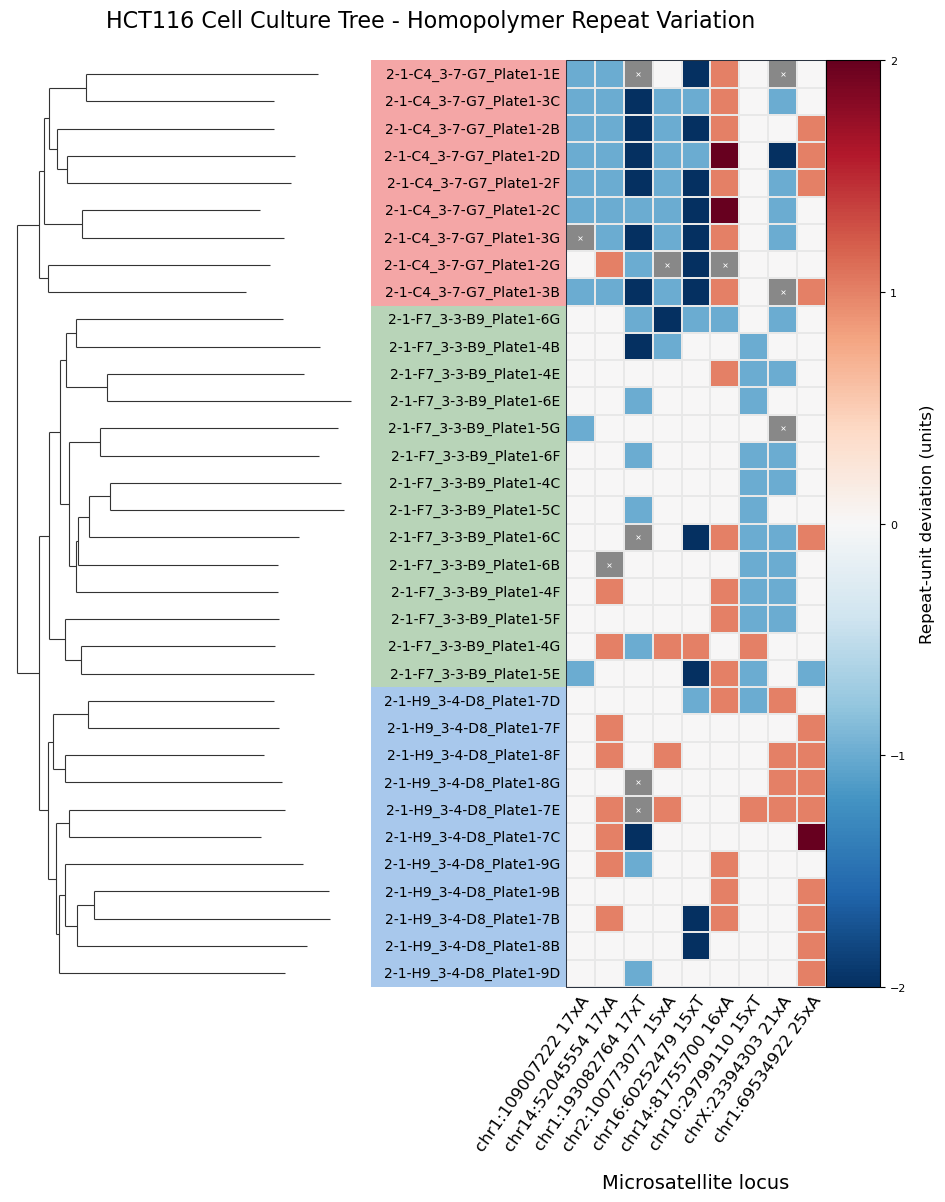

In [10]:
# ── Draw the combined figure ──────────────────────────────────────────────────
#
# Values are allele-based, then each column shifted by its display mode/median (see VISUAL_COLUMN_*).
# White ≈ most common **plotted** deviation in that column; scale still ±VMAX repeat units.

FONT_TICK = 9                    # misc small text (colour bar ticks, defaults)
FONT_CELL_TICK = 10               # heatmap row labels (cell names) — tweak up/down
FONT_LOCI_TICK = 12               # heatmap column (locus) labels — bigger than row names
FONT_CBAR_TITLE = FONT_LOCI_TICK  # vertical colour-bar title — match locus readability
FONT_LABEL = 14
FONT_TITLE = 16

print('[heatmap] seaborn heatmap (pcolormesh grid) + outer frame')

# Larger FIG_SCALE → taller/wider PDF with bigger heatmap cells (same data layout).
FIG_SCALE = 1.8
row_height = 0.18 * FIG_SCALE           # inches per heatmap row
col_width = 0.16 * FIG_SCALE
tree_width = 2.0 * FIG_SCALE
BAR_STRIP_SCALE = 4.5     # widen ax_bar clone strip (>1 vs base 0.22 * FIG_SCALE)
bar_width = 0.24 * FIG_SCALE * BAR_STRIP_SCALE
cbar_width = 0.3 * FIG_SCALE
fig_w = tree_width + bar_width + n_loci_plot * col_width + cbar_width + 1.1
fig_h = n_cells_plot * row_height + 1.85

# Horizontal gap between *each* adjacent column (fraction of subplot width); raises tree↔heatmap feel too.
WSPACE = 0

fig = plt.figure(figsize=(fig_w, fig_h))
gs = GridSpec(
    1, 4, figure=fig,
    width_ratios=[tree_width, bar_width, n_loci_plot * col_width, cbar_width],
    wspace=WSPACE,
    left=0.07, right=0.96, top=0.88, bottom=0.16
)
ax_tree = fig.add_subplot(gs[0])
ax_bar  = fig.add_subplot(gs[1])
ax_heat = fig.add_subplot(gs[2])
ax_cbar = fig.add_subplot(gs[3])

n_heatmap_rows = n_cells_plot

# ── 1. Tree — one leaf row per cell (matches heatmap row index) ─────────────
x_pos2, y_pos2 = {}, {}

def assign_x2(clade, depth=0.0):
    x_pos2[id(clade)] = depth
    for child in clade.clades:
        assign_x2(child, depth + (child.branch_length or 0.0))

def assign_y2(clade, counter):
    if clade.is_terminal():
        y = counter[0]
        counter[0] += 1
    else:
        child_ys = [assign_y2(child, counter) for child in clade.clades]
        y = np.mean(child_ys)
    y_pos2[id(clade)] = y
    return y

assign_x2(tree.root)
assign_y2(tree.root, [0])
draw_tree(ax_tree, tree, x_pos2, y_pos2, n_heatmap_rows)

# ── 2. Clone colour bar — one row per cell ───────────────────────────────────
for i, color in enumerate(cell_clone_colors):
    ax_bar.add_patch(mpatches.Rectangle((0, i - 0.5), 1, 1, color=color, linewidth=0))
ax_bar.set_xlim(0, 1)
ax_bar.set_ylim(n_heatmap_rows - 0.5, -0.5)
ax_bar.axis('off')

# ── 3. Heatmap ────────────────────────────────────────────────────────────────
cmap = plt.cm.RdBu_r.copy()
cmap.set_bad('#888888')

norm_hm = TwoSlopeNorm(vmin=float(VMIN), vcenter=0.0, vmax=float(VMAX))
data_masked = np.ma.masked_invalid(heatmap_array.astype(float))

# Seaborn draws the same linewidth + linecolor on *every* pcolormesh edge, so tune for
# a faint interior grid then overlay a separate outer frame above the grey cell grid.
GRID_LW, GRID_GREY = 0.02, '0.91'
FRAME_LW, FRAME_COLOR = 0.75, '#2b3340'

hm = sns.heatmap(
    data_masked,
    ax=ax_heat,
    cmap=cmap,
    norm=norm_hm,
    cbar=False,
    xticklabels=locus_labels,
    yticklabels=cell_labels,
    linewidths=GRID_LW,
    linecolor=GRID_GREY,
    zorder=1,
)
im = hm.collections[0]
im.set_rasterized(True)
ax_heat.set_aspect('auto')
ax_heat.grid(False)
for spine in ax_heat.spines.values():
    spine.set_visible(False)

ax_heat.add_patch(mpatches.Rectangle(
    (0, 0),
    float(n_loci_plot),
    float(n_cells_plot),
    fill=False,
    edgecolor=FRAME_COLOR,
    linewidth=FRAME_LW,
    zorder=8,
    clip_on=False,
))

nan_rows, nan_cols = np.where(np.isnan(heatmap_array))
# seaborn uses half-integer cell centers (same convention as its pcolormesh ticks)
ax_heat.scatter(
    nan_cols + 0.5, nan_rows + 0.5,
    marker='x', s=8, c='white', linewidths=0.55, zorder=11,
)

# Row / column labels (fontsize + x tilt; seaborn already placed ticks at cell centers)
ax_heat.tick_params(axis='y', which='major', left=True, labelleft=True, right=False, labelright=False,
                     length=0, pad=4)
for t in ax_heat.get_yticklabels():
    t.set_fontsize(FONT_CELL_TICK)

plt.setp(
    ax_heat.get_xticklabels(),
    fontsize=FONT_LOCI_TICK,
    rotation=55,
    ha='right',
    rotation_mode='anchor',
)
ax_heat.tick_params(axis='x', which='major', length=0, pad=4)
ax_heat.set_xlabel('Microsatellite locus', fontsize=FONT_LABEL, labelpad=14)

# ── 4. Colour bar ────────────────────────────────────────────────────────────
cb = fig.colorbar(im, cax=ax_cbar, orientation='vertical')
_cb_lbl = 'Repeat-unit deviation (units)'
cb.set_label(_cb_lbl, fontsize=FONT_CBAR_TITLE, labelpad=10)
cb.ax.tick_params(labelsize=FONT_TICK - 1)
cb.set_ticks([VMIN, -1, 0, 1, VMAX])

fig.suptitle(
    'HCT116 Cell Culture Tree - Homopolymer Repeat Variation',
    fontsize=FONT_TITLE, y=0.92
)

plt.savefig(OUT_PDF, bbox_inches='tight', pad_inches=0.15)
plt.savefig(OUT_PNG, dpi=200, bbox_inches='tight', pad_inches=0.15)
print(f'Saved {OUT_PDF} and {OUT_PNG}')
plt.show()



## CA2nt24k

Same pipeline using `results_CA2nt24k_500targets_minqual0_minreads10/` and `20210920_HCT116_2-6nt24k_samplesheet.csv`.

The **CA paths** cell sets file paths **and CA-only filter parameters** (`MIN_COVERAGE`, `MIN_F_STAT`, colour scale limits, normalization/display options, …). Tune those there so CA differs from TW without editing the TW subsection. With a **fresh kernel**, run **imports** then this section in order (**paths → … → plot**).


In [11]:
# ── Paths (CA2nt24k) ─────────────────────────────────────────────────────────
BASE = 'results_CA2nt24k_500targets_minqual0_minreads10'
VCF_PATH        = f'{BASE}/hipstr/20210920_HCT116_CA2nt24k.vcf'
TREE_PATH       = f'{BASE}/phylo/20210920_HCT116_CA2nt24k_rerun.buildPhylo.newick-bootstrap.txt'
SAMPLE_LIST     = f'{BASE}/hipstr/20210920_HCT116_CA2nt24k.sample_list.txt'
SAMPLE_SHEET    = '20210920_HCT116_2-6nt24k_samplesheet.csv'

OUT_PDF         = '20210920_HCT116_CA2nt24k_phylo_heatmap.pdf'
OUT_PNG         = '20210920_HCT116_CA2nt24k_phylo_heatmap.png'

# ── Filtering & heatmap/display for CA (independent of TW cell 3 above) ─────
# Tune these without changing the TW1nt12k block. They override globals if that cell ran earlier.
MIN_COVERAGE    = 0.70   # e.g. lower (0.65–0.80) if colony calls are sparser than TW
MIN_STD         = 0.00   # same knob as TW paths (unused in current cells; kept for parity)
ALLELE_BASELINE = 'median'
BASELINE_INTEGER = True
VISUAL_COLUMN_CENTER = True
VISUAL_COLUMN_STAT = 'mode'
VMIN, VMAX      = -2, 2  # diverging scale on heatmap / ± filter in normalization
MAX_LOCI        = 150
MIN_F_STAT      = 6.0    # ANOVA F cutoff — lower ⇒ more loci/columns (TW default 7)


In [12]:
# ── Parse VCF → GB matrix (repeat-unit change from reference) ───────────────
def parse_vcf_both_alleles(vcf_path, keep_samples=None):
    """
    Parse a HipSTR VCF and return TWO DataFrames (rows=loci, cols=samples):
        gb_lo  — the smaller of the two phased alleles (repeat-unit change)
        gb_hi  — the larger of the two phased alleles

    Both alleles are kept as separate integer repeat-unit values.
    We sort lo≤hi so the representation is consistent regardless of the
    arbitrary HipSTR phasing assignment (which allele is 'first' in a
    single-cell WGA diploid call has no meaningful biological interpretation).
    NaN where the call is missing.
    """
    rows_lo, rows_hi = [], []
    samples = None
    keep    = set(keep_samples) if keep_samples is not None else None

    with open(vcf_path) as fh:
        for line in fh:
            if line.startswith('##'):
                continue
            if line.startswith('#CHROM'):
                samples = line.lstrip('#').strip().split('\t')[9:]
                continue

            fields   = line.strip().split('\t')
            locus_id = fields[2]
            fmt_keys = fields[8].split(':')
            if 'GB' not in fmt_keys:
                continue
            gb_idx = fmt_keys.index('GB')

            period = 1
            for tag in fields[7].split(';'):
                if tag.startswith('PERIOD='):
                    period = int(tag.split('=')[1])
                    break

            row_lo = {'locus': locus_id}
            row_hi = {'locus': locus_id}
            for i, samp in enumerate(samples):
                if keep is not None and samp not in keep:
                    continue
                sval   = fields[9 + i].split(':')
                gb_str = sval[gb_idx] if gb_idx < len(sval) else '.'

                if gb_str == '.' or '.' in gb_str.split('|'):
                    row_lo[samp] = row_hi[samp] = np.nan
                    continue
                try:
                    a1, a2 = sorted(float(x) / period for x in gb_str.split('|'))
                    row_lo[samp] = a1   # smaller allele
                    row_hi[samp] = a2   # larger allele
                except ValueError:
                    row_lo[samp] = row_hi[samp] = np.nan

            rows_lo.append(row_lo)
            rows_hi.append(row_hi)

    def _to_df(rows):
        df = pd.DataFrame(rows).set_index('locus')
        if keep_samples is not None:
            df = df[[s for s in keep_samples if s in df.columns]]
        return df

    return _to_df(rows_lo), _to_df(rows_hi)


sample_list = open(SAMPLE_LIST).read().strip().split('\n')
print(f'Samples: {len(sample_list)}')

gb_lo, gb_hi = parse_vcf_both_alleles(VCF_PATH, keep_samples=sample_list)
print(f'Both-allele matrices: {gb_lo.shape[0]} loci × {gb_lo.shape[1]} cells')
print('gb_lo = smaller allele, gb_hi = larger allele')
gb_lo.head(3)


Samples: 49
Both-allele matrices: 4913 loci × 49 cells
gb_lo = smaller allele, gb_hi = larger allele


,2-1-C4_3-7-G7_Plate2-1B,2-1-C4_3-7-G7_Plate2-1C,2-1-C4_3-7-G7_Plate2-1D,2-1-C4_3-7-G7_Plate2-1E,2-1-C4_3-7-G7_Plate2-2B,2-1-C4_3-7-G7_Plate2-2C,2-1-C4_3-7-G7_Plate2-2D,2-1-C4_3-7-G7_Plate2-2E,2-1-C4_3-7-G7_Plate2-2F,2-1-C4_3-7-G7_Plate2-2G,...,2-1-H9_3-4-D8_Plate2-8B,2-1-H9_3-4-D8_Plate2-8D,2-1-H9_3-4-D8_Plate2-8E,2-1-H9_3-4-D8_Plate2-8F,2-1-H9_3-4-D8_Plate2-8G,2-1-H9_3-4-D8_Plate2-9B,2-1-H9_3-4-D8_Plate2-9C,2-1-H9_3-4-D8_Plate2-9D,2-1-H9_3-4-D8_Plate2-9F,2-1-H9_3-4-D8_Plate2-9G
locus,,,,,,,,,,,,,,,,,,,,,
chr1:2118713-2118755_21xTG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN,...,2.0,4.0,NaN,NaN,NaN,NaN,5.0,3.0,NaN,NaN
chr1:3668515-3668547_16xGT,NaN,NaN,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chr1:5806171-5806203_16xAC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,3.0,NaN,NaN,-3.0,NaN,NaN


In [13]:
# ── Coverage filter (applied to both allele matrices jointly) ─────────────────
# A locus passes if both alleles are called in ≥ MIN_COVERAGE of cells.
coverage = (gb_lo.notna() & gb_hi.notna()).mean(axis=1)
loci_covered = coverage[coverage >= MIN_COVERAGE].index
print(f'Loci with ≥{MIN_COVERAGE*100:.0f}% coverage (both alleles): {len(loci_covered)}')

gb_lo_filt = gb_lo.loc[loci_covered]
gb_hi_filt = gb_hi.loc[loci_covered]


Loci with ≥70% coverage (both alleles): 407


In [14]:
# ── Normalize each locus to a pooled baseline (median or mode of alleles) ─────
#
# Subtract pooled baseline (median or mode). With BASELINE_INTEGER, alleles are rounded to the nearest repeat before computing baseline,
# then baseline is rounded to int — fixes columns that look wrong when the raw median sits between 11 and 12 (many ±0.5 vs ±1).

MAX_NORM = VMAX

norm_lo, norm_hi = {}, {}
kept_loci = []

for locus in loci_covered:
    lo_vals = gb_lo_filt.loc[locus].dropna()
    hi_vals = gb_hi_filt.loc[locus].dropna()
    all_vals = pd.concat([lo_vals, hi_vals]).astype(float)
    if len(all_vals) == 0:
        continue
    pool = np.round(all_vals) if BASELINE_INTEGER else all_vals
    if ALLELE_BASELINE == 'median':
        raw = float(np.median(pool))
        baseline = float(round(raw)) if BASELINE_INTEGER else raw
    elif ALLELE_BASELINE == 'mode':
        modes = pd.Series(pool).mode()
        baseline = float(round(float(modes.iloc[0]))) if BASELINE_INTEGER else float(modes.iloc[0])
    else:
        raise ValueError("ALLELE_BASELINE must be 'median' or 'mode'")
    lo_norm = gb_lo_filt.loc[locus] - baseline
    hi_norm = gb_hi_filt.loc[locus] - baseline
    if lo_norm.dropna().abs().max() > MAX_NORM or hi_norm.dropna().abs().max() > MAX_NORM:
        continue
    norm_lo[locus] = lo_norm
    norm_hi[locus] = hi_norm
    kept_loci.append(locus)

gb_norm_lo = pd.DataFrame(norm_lo).T
gb_norm_hi = pd.DataFrame(norm_hi).T

print(f'Loci after ±{MAX_NORM} filter: {len(kept_loci)}  (dropped {len(loci_covered) - len(kept_loci)} noisy loci)')
ex = kept_loci[0] if kept_loci else None
if ex:
    print(f'\nExample locus: {ex}')
    print(f'  lo (first 5): {gb_norm_lo.loc[ex].dropna().values[:5]}')
    print(f'  hi (first 5): {gb_norm_hi.loc[ex].dropna().values[:5]}')



Loci after ±2 filter: 238  (dropped 169 noisy loci)

Example locus: chr1:17148447-17148482_7xAAACA
  lo (first 5): [-1.  0. -1. -1. -1.]
  hi (first 5): [-1.  0.  0. -1. -1.]


In [15]:
# ── Parse tree and compute layout ─────────────────────────────────────────────

def compute_tree_layout(tree):
    """
    Return (x_pos, y_pos, leaf_order) where:
      x_pos[clade_id] = cumulative branch length from root
      y_pos[clade_id] = display position (0=top, N-1=bottom)
      leaf_order      = list of leaf names, top→bottom
    """
    # Use clade id() as dict key since Clade objects are not hashable
    x_pos = {}
    y_pos = {}

    def assign_x(clade, depth=0.0):
        x_pos[id(clade)] = depth
        for child in clade.clades:
            assign_x(child, depth + (child.branch_length or 0.0))

    def assign_y(clade, counter):
        """Post-order: leaves get sequential integers, internal = mean of children."""
        if clade.is_terminal():
            y = counter[0]
            counter[0] += 1
        else:
            child_ys = [assign_y(child, counter) for child in clade.clades]
            y = np.mean(child_ys)
        y_pos[id(clade)] = y
        return y

    assign_x(tree.root)
    assign_y(tree.root, [0])

    leaf_order = [leaf.name for leaf in tree.get_terminals()]
    return x_pos, y_pos, leaf_order


def draw_tree(ax, tree, x_pos, y_pos, n_leaves, lw=0.8, color='#333333'):
    """Draw phylogram on ax (root on left, leaves on right)."""

    def _draw(clade):
        x = x_pos[id(clade)]
        y = y_pos[id(clade)]
        for child in clade.clades:
            cx = x_pos[id(child)]
            cy = y_pos[id(child)]
            ax.plot([x, cx], [cy, cy], color=color, lw=lw, solid_capstyle='butt')
            _draw(child)
        if clade.clades:
            child_ys = [y_pos[id(c)] for c in clade.clades]
            ax.plot([x, x], [min(child_ys), max(child_ys)],
                    color=color, lw=lw, solid_capstyle='butt')

    _draw(tree.root)
    x_max = max(x_pos.values())
    ax.set_xlim(-x_max * 0.02, x_max * 1.06)
    ax.set_ylim(-0.5, n_leaves - 0.5)
    ax.invert_yaxis()
    ax.axis('off')


# Load tree
tree = Phylo.read(TREE_PATH, 'newick')
x_pos, y_pos, leaf_order = compute_tree_layout(tree)
n_leaves = len(leaf_order)
print(f'Tree leaves: {n_leaves}')
print('First 5 leaves (top→bottom):', leaf_order[:5])


Tree leaves: 49
First 5 leaves (top→bottom): ['2-1-C4_3-7-G7_Plate2-1B', '2-1-C4_3-7-G7_Plate2-3G', '2-1-C4_3-7-G7_Plate2-1C', '2-1-C4_3-7-G7_Plate2-3C', '2-1-C4_3-7-G7_Plate2-1D']


In [16]:
# ── F-statistic selection + clone-group column ordering ───────────────────────
from scipy import stats as sp_stats

# MIN_F_STAT is set in the CA paths cell at the top of this section — do not redefine here.

cells_in_both = [c for c in leaf_order if c in gb_norm_lo.columns]

clone_map   = {c: c.split('_')[0].split('-')[2] for c in cells_in_both}
clone_cells = {}
for cell, clone in clone_map.items():
    clone_cells.setdefault(clone, []).append(cell)
print('Clones (tree order):', {c: len(v) for c, v in clone_cells.items()})

# Same as heatmap: one value per cell per locus (farthest-from-baseline call, signed)
lo_all = gb_norm_lo.loc[kept_loci, cells_in_both].T.to_numpy(dtype=float)
hi_all = gb_norm_hi.loc[kept_loci, cells_in_both].T.to_numpy(dtype=float)
only_lo = np.isfinite(lo_all) & ~np.isfinite(hi_all)
only_hi = ~np.isfinite(lo_all) & np.isfinite(hi_all)
both = np.isfinite(lo_all) & np.isfinite(hi_all)
neither = ~np.isfinite(lo_all) & ~np.isfinite(hi_all)
plot_stat_arr = np.full(lo_all.shape, np.nan)
plot_stat_arr[neither] = np.nan
plot_stat_arr[only_lo] = lo_all[only_lo]
plot_stat_arr[only_hi] = hi_all[only_hi]
pick_lo = np.abs(lo_all[both]) >= np.abs(hi_all[both])
plot_stat_arr[both] = np.where(pick_lo, lo_all[both], hi_all[both])
plot_stat_df = pd.DataFrame(plot_stat_arr, index=cells_in_both, columns=kept_loci)

# F on exactly those plotted values (one obs per cell; no double-counting alleles)
f_scores = {}
for locus in kept_loci:
    groups = [plot_stat_df.loc[clone_cells[c], locus].dropna().values for c in clone_cells]
    if any(len(g) < 2 for g in groups):
        continue
    f, _ = sp_stats.f_oneway(*groups)
    f_scores[locus] = f if np.isfinite(f) else 0.0

f_series = pd.Series(f_scores).sort_values(ascending=False)
sig_loci = f_series[f_series >= MIN_F_STAT].index.tolist()
print(f'Loci with F >= {MIN_F_STAT}: {len(sig_loci)}')


def outlier_clone(locus):
    means = {c: plot_stat_df.loc[clone_cells[c], locus].mean() for c in clone_cells}
    max_dev, winner = 0, None
    for c, m in means.items():
        others = [v for k, v in means.items() if k != c]
        dev = abs(m - np.mean(others))
        if dev > max_dev:
            max_dev, winner = dev, c
    return winner

group_order = ['C4', 'H9', 'F7']  # CA2nt24k: scaffolds G7 → D8 → B9 (matches 2-1-C4 / 2-1-H9 / 2-1-F7)
loci_ordered, group_boundaries = [], {}
col = 0
for clone in group_order:
    grp = sorted([l for l in sig_loci if outlier_clone(l) == clone], key=lambda l: -f_series[l])
    group_boundaries[clone] = (col, col + len(grp))
    loci_ordered += grp
    col += len(grp)

print(f'\nLoci per clone group:')
for clone in group_order:
    s, e = group_boundaries[clone]
    print(f'  {clone}: {e-s} loci')

n_cells_plot = len(cells_in_both)
n_loci_plot = len(loci_ordered)
heatmap_array = plot_stat_df.loc[cells_in_both, loci_ordered].to_numpy(dtype=float).copy()

# Display-only: column-wise center on mode/median of values actually drawn (F / locus order still use plot_stat_df above).
if VISUAL_COLUMN_CENTER:
    for j in range(heatmap_array.shape[1]):
        mask = np.isfinite(heatmap_array[:, j])
        if not mask.any():
            continue
        v = heatmap_array[mask, j].copy()
        if VISUAL_COLUMN_STAT == 'mode':
            mo = pd.Series(v).mode()
            shift = float(mo.iloc[0]) if len(mo) else float(np.median(v))
        elif VISUAL_COLUMN_STAT == 'median':
            shift = float(np.median(v))
        else:
            raise ValueError("VISUAL_COLUMN_STAT must be 'mode' or 'median'")
        heatmap_array[mask, j] = v - shift

def short_locus_label(locus_id):
    parts     = locus_id.rsplit('_', 1)
    chrom_pos = parts[0].split(':')[0] + ':' + parts[0].split(':')[1].split('-')[0]
    motif     = parts[1] if len(parts) > 1 else ''
    return f'{chrom_pos} {motif}'


locus_labels = [short_locus_label(l) for l in loci_ordered]
cell_labels  = list(cells_in_both)

sfx = f"; columns {VISUAL_COLUMN_STAT}-centered for display" if VISUAL_COLUMN_CENTER else ""
print(f'\nHeatmap: {heatmap_array.shape[0]} rows × {n_loci_plot} cols — '
      f'per cell, farthest vs pooled allele baseline ({ALLELE_BASELINE}){sfx}')



Clones (tree order): {'C4': 15, 'H9': 16, 'F7': 18}
Loci with F >= 6.0: 10

Loci per clone group:
  C4: 4 loci
  H9: 2 loci
  F7: 4 loci

Heatmap: 49 rows × 10 cols — per cell, farthest vs pooled allele baseline (median); columns mode-centered for display


In [17]:
# ── Clone colour annotation (samplesheet `group` + `color`) ────────────────
_ss = pd.read_csv(SAMPLE_SHEET)
CLONE_COLORS = {}
for _, _row in _ss.drop_duplicates('group').iterrows():
    _gid = str(_row['group'])
    _clone = _gid.split('_')[0].split('-')[2]
    CLONE_COLORS[_clone] = str(_row['color']).strip()
DEFAULT_CLONE_COLOR = '#AAAAAA'

def get_clone(cell_name):
    """Extract clone ID from cell name, e.g. '2-1-C4_...' → 'C4'."""
    return cell_name.split('_')[0].split('-')[2]

cell_clone_colors = [
    CLONE_COLORS.get(get_clone(c), DEFAULT_CLONE_COLOR)
    for c in cells_in_both
]

print('Clone breakdown:')
for c in cells_in_both:
    print(f'  {c}  →  {get_clone(c)}')
print('Colors from samplesheet:', CLONE_COLORS)



Clone breakdown:
  2-1-C4_3-7-G7_Plate2-1B  →  C4
  2-1-C4_3-7-G7_Plate2-3G  →  C4
  2-1-C4_3-7-G7_Plate2-1C  →  C4
  2-1-C4_3-7-G7_Plate2-3C  →  C4
  2-1-C4_3-7-G7_Plate2-1D  →  C4
  2-1-C4_3-7-G7_Plate2-3D  →  C4
  2-1-C4_3-7-G7_Plate2-2E  →  C4
  2-1-C4_3-7-G7_Plate2-1E  →  C4
  2-1-C4_3-7-G7_Plate2-2C  →  C4
  2-1-C4_3-7-G7_Plate2-2F  →  C4
  2-1-C4_3-7-G7_Plate2-2B  →  C4
  2-1-C4_3-7-G7_Plate2-2G  →  C4
  2-1-C4_3-7-G7_Plate2-2D  →  C4
  2-1-C4_3-7-G7_Plate2-3B  →  C4
  2-1-H9_3-4-D8_Plate2-9B  →  H9
  2-1-F7_3-3-B9_Plate2-4D  →  F7
  2-1-H9_3-4-D8_Plate2-9C  →  H9
  2-1-H9_3-4-D8_Plate2-9F  →  H9
  2-1-H9_3-4-D8_Plate2-7F  →  H9
  2-1-H9_3-4-D8_Plate2-8B  →  H9
  2-1-H9_3-4-D8_Plate2-9G  →  H9
  2-1-H9_3-4-D8_Plate2-7G  →  H9
  2-1-H9_3-4-D8_Plate2-8E  →  H9
  2-1-C4_3-7-G7_Plate2-3E  →  C4
  2-1-H9_3-4-D8_Plate2-7E  →  H9
  2-1-H9_3-4-D8_Plate2-8F  →  H9
  2-1-H9_3-4-D8_Plate2-9D  →  H9
  2-1-H9_3-4-D8_Plate2-7B  →  H9
  2-1-H9_3-4-D8_Plate2-8G  →  H9
  2-1-H9_3-4-D8_Plate2-8D 

[heatmap] seaborn heatmap (pcolormesh grid) + outer frame
Saved 20210920_HCT116_CA2nt24k_phylo_heatmap.pdf and 20210920_HCT116_CA2nt24k_phylo_heatmap.png


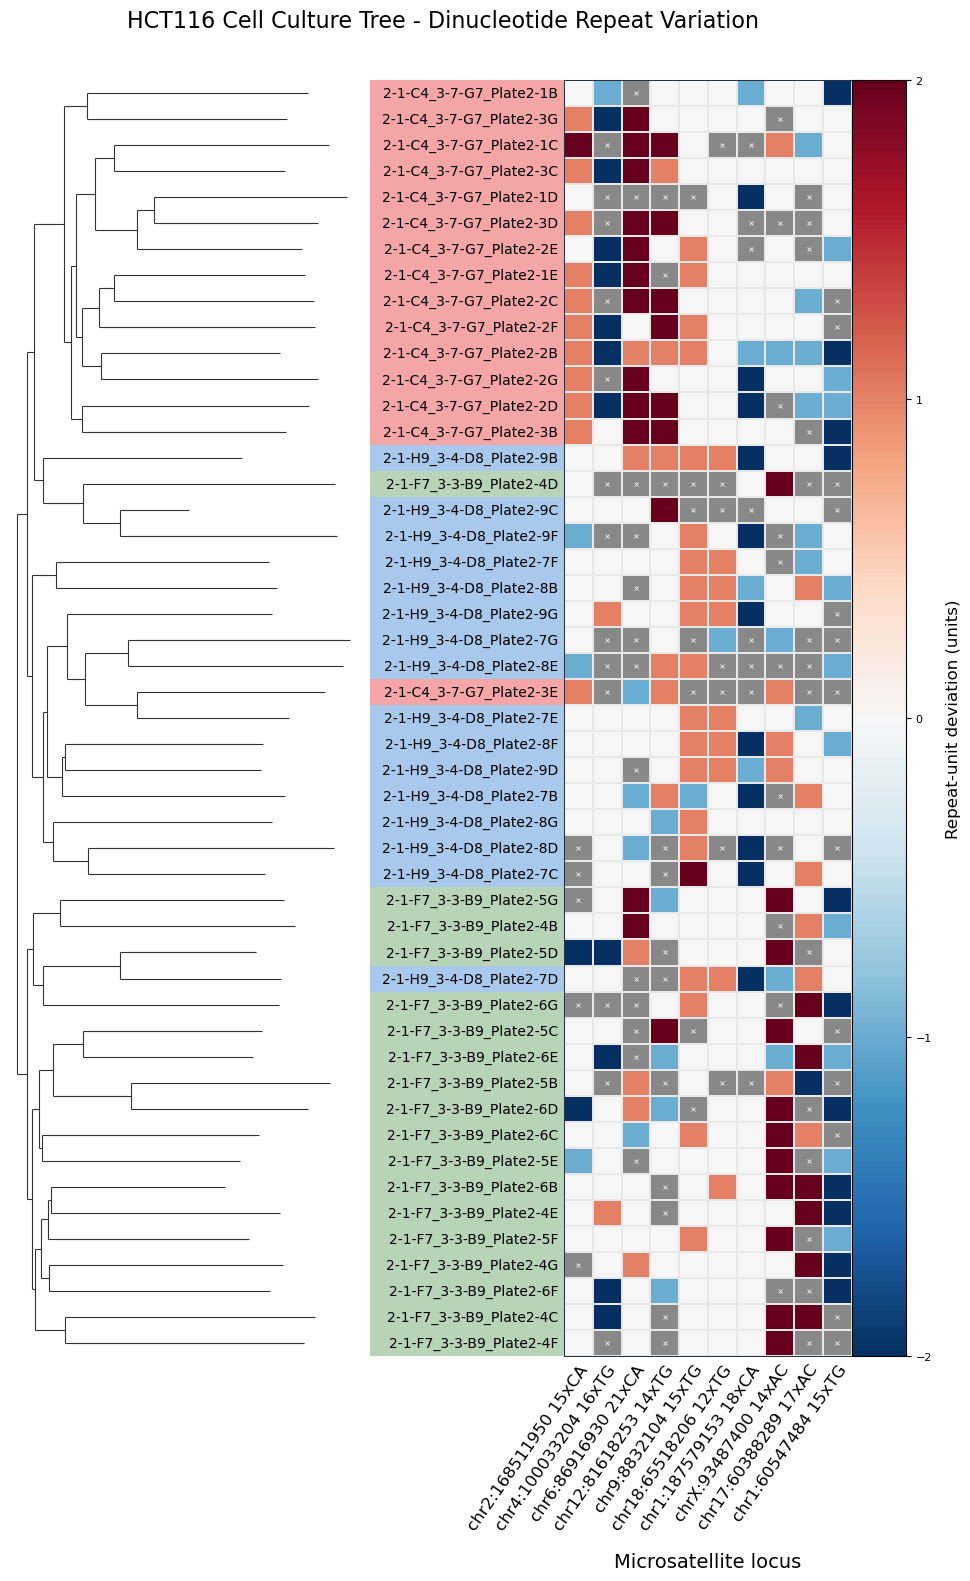

In [18]:
# ── Draw the combined figure ──────────────────────────────────────────────────
#
# Values are allele-based, then each column shifted by its display mode/median (see VISUAL_COLUMN_*).
# White ≈ most common **plotted** deviation in that column; scale still ±VMAX repeat units.

FONT_TICK = 9                    # misc small text (colour bar ticks, defaults)
FONT_CELL_TICK = 10               # heatmap row labels (cell names) — tweak up/down
FONT_LOCI_TICK = 12               # heatmap column (locus) labels — bigger than row names
FONT_CBAR_TITLE = FONT_LOCI_TICK  # vertical colour-bar title — match locus readability
FONT_LABEL = 14
FONT_TITLE = 16

print('[heatmap] seaborn heatmap (pcolormesh grid) + outer frame')

# Larger FIG_SCALE → taller/wider PDF with bigger heatmap cells (same data layout).
FIG_SCALE = 1.8
row_height = 0.18 * FIG_SCALE           # inches per heatmap row
col_width = 0.16 * FIG_SCALE
tree_width = 2.0 * FIG_SCALE
BAR_STRIP_SCALE = 4.5     # widen ax_bar clone strip (>1 vs base 0.22 * FIG_SCALE)
bar_width = 0.24 * FIG_SCALE * BAR_STRIP_SCALE
cbar_width = 0.3 * FIG_SCALE
fig_w = tree_width + bar_width + n_loci_plot * col_width + cbar_width + 1.1
fig_h = n_cells_plot * row_height + 1.85

# Horizontal gap between *each* adjacent column (fraction of subplot width); raises tree↔heatmap feel too.
WSPACE = 0

fig = plt.figure(figsize=(fig_w, fig_h))
gs = GridSpec(
    1, 4, figure=fig,
    width_ratios=[tree_width, bar_width, n_loci_plot * col_width, cbar_width],
    wspace=WSPACE,
    left=0.07, right=0.96, top=0.88, bottom=0.16
)
ax_tree = fig.add_subplot(gs[0])
ax_bar  = fig.add_subplot(gs[1])
ax_heat = fig.add_subplot(gs[2])
ax_cbar = fig.add_subplot(gs[3])

n_heatmap_rows = n_cells_plot

# ── 1. Tree — one leaf row per cell (matches heatmap row index) ─────────────
x_pos2, y_pos2 = {}, {}

def assign_x2(clade, depth=0.0):
    x_pos2[id(clade)] = depth
    for child in clade.clades:
        assign_x2(child, depth + (child.branch_length or 0.0))

def assign_y2(clade, counter):
    if clade.is_terminal():
        y = counter[0]
        counter[0] += 1
    else:
        child_ys = [assign_y2(child, counter) for child in clade.clades]
        y = np.mean(child_ys)
    y_pos2[id(clade)] = y
    return y

assign_x2(tree.root)
assign_y2(tree.root, [0])
draw_tree(ax_tree, tree, x_pos2, y_pos2, n_heatmap_rows)

# ── 2. Clone colour bar — one row per cell ───────────────────────────────────
for i, color in enumerate(cell_clone_colors):
    ax_bar.add_patch(mpatches.Rectangle((0, i - 0.5), 1, 1, color=color, linewidth=0))
ax_bar.set_xlim(0, 1)
ax_bar.set_ylim(n_heatmap_rows - 0.5, -0.5)
ax_bar.axis('off')

# ── 3. Heatmap ────────────────────────────────────────────────────────────────
cmap = plt.cm.RdBu_r.copy()
cmap.set_bad('#888888')

norm_hm = TwoSlopeNorm(vmin=float(VMIN), vcenter=0.0, vmax=float(VMAX))
data_masked = np.ma.masked_invalid(heatmap_array.astype(float))

# Seaborn draws the same linewidth + linecolor on *every* pcolormesh edge, so tune for
# a faint interior grid then overlay a separate outer frame above the grey cell grid.
GRID_LW, GRID_GREY = 0.02, '0.91'
FRAME_LW, FRAME_COLOR = 0.75, '#2b3340'

hm = sns.heatmap(
    data_masked,
    ax=ax_heat,
    cmap=cmap,
    norm=norm_hm,
    cbar=False,
    xticklabels=locus_labels,
    yticklabels=cell_labels,
    linewidths=GRID_LW,
    linecolor=GRID_GREY,
    zorder=1,
)
im = hm.collections[0]
im.set_rasterized(True)
ax_heat.set_aspect('auto')
ax_heat.grid(False)
for spine in ax_heat.spines.values():
    spine.set_visible(False)

ax_heat.add_patch(mpatches.Rectangle(
    (0, 0),
    float(n_loci_plot),
    float(n_cells_plot),
    fill=False,
    edgecolor=FRAME_COLOR,
    linewidth=FRAME_LW,
    zorder=8,
    clip_on=False,
))

nan_rows, nan_cols = np.where(np.isnan(heatmap_array))
# seaborn uses half-integer cell centers (same convention as its pcolormesh ticks)
ax_heat.scatter(
    nan_cols + 0.5, nan_rows + 0.5,
    marker='x', s=8, c='white', linewidths=0.55, zorder=11,
)

# Row / column labels (fontsize + x tilt; seaborn already placed ticks at cell centers)
ax_heat.tick_params(axis='y', which='major', left=True, labelleft=True, right=False, labelright=False,
                     length=0, pad=4)
for t in ax_heat.get_yticklabels():
    t.set_fontsize(FONT_CELL_TICK)

plt.setp(
    ax_heat.get_xticklabels(),
    fontsize=FONT_LOCI_TICK,
    rotation=55,
    ha='right',
    rotation_mode='anchor',
)
ax_heat.tick_params(axis='x', which='major', length=0, pad=4)
ax_heat.set_xlabel('Microsatellite locus', fontsize=FONT_LABEL, labelpad=14)

# ── 4. Colour bar ────────────────────────────────────────────────────────────
cb = fig.colorbar(im, cax=ax_cbar, orientation='vertical')
_cb_lbl = 'Repeat-unit deviation (units)'
cb.set_label(_cb_lbl, fontsize=FONT_CBAR_TITLE, labelpad=10)
cb.ax.tick_params(labelsize=FONT_TICK - 1)
cb.set_ticks([VMIN, -1, 0, 1, VMAX])

fig.suptitle(
    'HCT116 Cell Culture Tree - Dinucleotide Repeat Variation',
    fontsize=FONT_TITLE, y=0.92
)

plt.savefig(OUT_PDF, bbox_inches='tight', pad_inches=0.15)
plt.savefig(OUT_PNG, dpi=200, bbox_inches='tight', pad_inches=0.15)
print(f'Saved {OUT_PDF} and {OUT_PNG}')
plt.show()

